In [1]:
import os
import sys
import numpy as np
import pandas as pd

notebook_path = os.getcwd()
# Go up one level to reach the common parent of f1 and f2
parent_path = os.path.abspath(os.path.join(notebook_path, '..'))

if parent_path not in sys.path:
    sys.path.append(parent_path)

from market_data import KalshiAnalyzer, KalshiClient, KalshiFeatureEngineer, KalshiSportsManager

In [2]:
manager = KalshiSportsManager()

sports_series = manager.get_all_sports_series(volume_thresh=1e7, n_ticker=100)
active_tickers = manager.get_all_active_tickers(sports_series) 


Filtering Tickers:  26%|██▌       | 33/129 [00:07<00:15,  6.08it/s]

Skipping series KXMLBHRDERBY: 429 Client Error: Too Many Requests for url: https://api.elections.kalshi.com/trade-api/v2/markets?series_ticker=KXMLBHRDERBY&status=open&limit=1000


Filtering Tickers:  27%|██▋       | 35/129 [00:08<00:14,  6.32it/s]

Skipping series KXBUNDESLIGAGAME: 429 Client Error: Too Many Requests for url: https://api.elections.kalshi.com/trade-api/v2/markets?series_ticker=KXBUNDESLIGAGAME&status=open&limit=1000


Filtering Tickers:  29%|██▊       | 37/129 [00:08<00:13,  6.60it/s]

...

Filtering Tickers:  46%|████▌     | 59/129 [00:12<00:10,  6.72it/s]

Skipping series KXNCAAFTOTAL: 429 Client Error: Too Many Requests for url: https://api.elections.kalshi.com/trade-api/v2/markets?series_ticker=KXNCAAFTOTAL&status=open&limit=1000


Filtering Tickers:  49%|████▉     | 63/129 [00:12<00:10,  6.34it/s]

Skipping series KXNBAMVP: 429 Client Error: Too Many Requests for url: https://api.elections.kalshi.com/trade-api/v2/markets?series_ticker=KXNBAMVP&status=open&limit=1000


Filtering Tickers: 100%|██████████| 129/129 [00:31<00:00,  4.16it/s]


In [6]:
len(active_tickers)

512

In [7]:
s_ticker, ticker = active_tickers[np.random.randint(len(active_tickers))]
dataset_builder = KalshiFeatureEngineer(s_ticker, ticker)
data = dataset_builder.get_price_volume_data()
data

,price,vol_yes,vol_no,vol_total
2026-02-06 05:00:00+00:00,0.0,0.0,0.0,0.0
2026-02-07 05:00:00+00:00,0.0,0.0,0.0,0.0
2026-02-08 05:00:00+00:00,0.0,0.0,0.0,0.0
2026-02-09 05:00:00+00:00,0.0,0.0,0.0,0.0
2026-02-10 05:00:00+00:00,0.0,0.0,0.0,0.0
2026-02-13 05:00:00+00:00,0.0,0.0,0.0,0.0
2026-02-14 05:00:00+00:00,0.0,467.0,0.0,467.0
2026-02-16 05:00:00+00:00,1.0,0.0,0.0,0.0
2026-02-17 05:00:00+00:00,1.0,150.0,0.0,150.0
2026-02-18 05:00:00+00:00,1.0,0.0,0.0,0.0


In [8]:
from tqdm import tqdm

dico_X, dico_y = {}, {}
for s_ticker, ticker in tqdm(active_tickers):
    dataset_builder = KalshiFeatureEngineer(s_ticker, ticker)
    X, y = dataset_builder.build_features()
    dico_X[ticker] = X
    dico_y[ticker] = y    

  0%|          | 0/512 [00:00<?, ?it/s]


TypeError: KalshiAnalyzer.get_price_volume_data() got an unexpected keyword argument 'days'

In [40]:
X = pd.concat(dico_X)
y = pd.concat(dico_y).loc[X.index].dropna()
X = X.loc[y.index]

/var/folders/b3/wb1ksqsd6tv5s9jff9pnm7hw0000gn/T/ipykernel_11589/2433715458.py:1: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  X = pd.concat(dico_X)
/var/folders/b3/wb1ksqsd6tv5s9jff9pnm7hw0000gn/T/ipykernel_11589/2433715458.py:2: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  y = pd.concat(dico_y).loc[X.index].dropna()


In [41]:
import lightgbm as lgb
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score

# 1. Tri chronologique strict (Niveau 1 du MultiIndex : Date)
X = X.sort_index(level=1)
y = y.reindex(X.index)

# Récupération des jours uniques présents dans le dataset
unique_days = X.index.get_level_values(1).unique().sort_values()

metrics = {'rmse': [], 'sign_acc': [], 'pnls': [], 'r2': []}
min_train_points = 50

# 2. Boucle d'Expanding Window par jour
for i in range(len(unique_days)):
    current_day = unique_days[i]
    
    # Données d'entraînement : tout ce qui est strictement avant le jour actuel
    train_mask = X.index.get_level_values(1) < current_day
    X_train, y_train = X[train_mask], y[train_mask]
    
    # Données de test : le jour actuel
    test_mask = X.index.get_level_values(1) == current_day
    X_test, y_test = X[test_mask], y[test_mask]
    
    # Condition : minimum 50 points pour entraîner
    if len(X_train) < min_train_points or len(X_test) == 0:
        continue
        
    # 3. Fit du nouveau modèle quotidien
    model = lgb.LGBMRegressor(n_estimators=100, learning_rate=0.05, verbosity=-1)
    model.fit(X_train, y_train)
    
    preds = model.predict(X_test)
    
    # 4. Métriques quotidiennes
    actual_sign = np.sign(y_test.values)
    pred_sign = np.sign(preds)
    
    mask = actual_sign != 0
    if np.any(mask):
        # Accuracy directionnelle
        acc = accuracy_score(actual_sign[mask], pred_sign[mask])
        # PnL (Gain moyen pondéré par direction)
        pnl = np.sum(actual_sign[mask] * pred_sign[mask]) / np.sum(np.abs(pred_sign[mask]))
        
        metrics['rmse'].append(np.sqrt(mean_squared_error(y_test, preds)))
        metrics['r2'].append(r2_score(y_test, preds))
        metrics['sign_acc'].append(acc)
        metrics['pnls'].append(pnl)

# 5. Synthèse des performances
print(f"Modèles entraînés : {len(metrics['pnls'])}")
print(f"Mean RMSE: {np.mean(metrics['rmse']):.4f}")
print(f"Mean r2: {np.mean(metrics['r2']):.4f}")
print(f"Mean Sign Accuracy: {np.mean(metrics['sign_acc']):.2%}")

Modèles entraînés : 28
Mean RMSE: 0.1912
Mean r2: 0.0539
Mean Sign Accuracy: 68.31%


<Axes: >

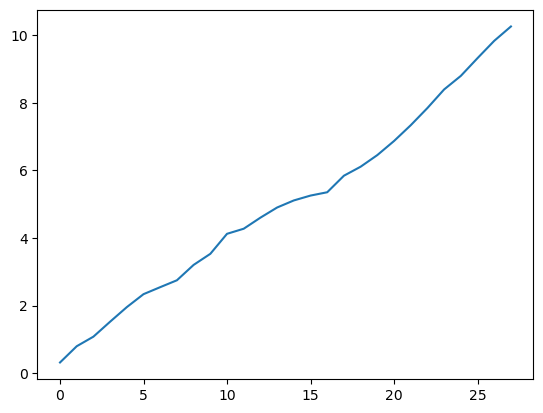

In [43]:
pnls = pd.Series(metrics["pnls"])
pnls.cumsum().plot()

In [46]:
16*pnls.mean()/pnls.std()

43.670356997575794

In [45]:
pnls.describe()

count    28.000000
mean      0.366234
std       0.134181
min       0.098214
25%       0.279068
50%       0.392050
75%       0.470079
max       0.592233
dtype: float64